In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

In [2]:
start = -1
end = 1
step = 0.02
X = torch.arange(start, end, step).reshape(-1,1)
y = np.sin(X*np.pi)

/tmp/ipykernel_49784/1951419740.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y = np.sin(X*np.pi)


In [3]:
class PINN(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=1, out_features=50)
    self.layer_2 = nn.Linear(in_features=50, out_features=50)
    self.layer_3 = nn.Linear(in_features=50, out_features=50)
    self.layer_output = nn.Linear(in_features=50, out_features=1)
    self.tanh = nn.Tanh()

  def forward(self, x):
    x = self.tanh(self.layer_1(x))
    x = self.tanh(self.layer_2(x))
    x = self.tanh(self.layer_3(x))
    x = self.layer_output(x)
    return x
model = PINN()

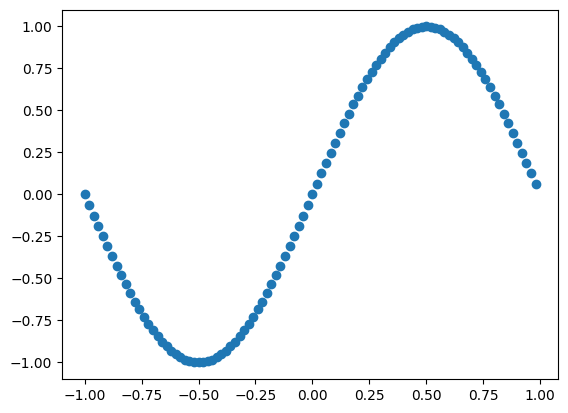

In [4]:
plt.scatter(X, y)

In [5]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100
    return acc

In [6]:
def get_derivative(y, x, n):
        # General formula to compute the n-th order derivative of y = f(x) with respect to x
        if n == 0:
            return y
        else:
            dy_dx = torch.autograd.grad(y, x, torch.ones_like(y), create_graph=True, retain_graph=True)[0]
        return get_derivative(dy_dx, x, n - 1)

In [7]:
def pde(X, model):

  X = X.clone().detach().requires_grad_(True)
  y = model(X)

  dy_dx = torch.autograd.grad(
      y,
      X,
      grad_outputs=torch.ones_like(y),
      create_graph=True
  )[0]

  d2y_dx2 = torch.autograd.grad(
      dy_dx,
      X,
      grad_outputs=torch.ones_like(dy_dx),
      create_graph=True
  )[0]

  return d2y_dx2 + torch.pi**2 * torch.sin(torch.pi * X)


In [16]:
def loss_fn(model, x, x_bc, y_bc):
    res = pde(x, model)
    loss_pde = torch.mean(res**2)
    y_bc_pred = model(x_bc)
    # Compute the mean squared error of the boundary conditions
    loss_bc = torch.mean((y_bc - y_bc_pred)**2)
    return loss_pde + loss_bc

optimizer = torch.optim.Adam(params=model.parameters(), # optimize newly created model's parameters
                            lr=0.01)

In [17]:
x_bc = np.array([[-1.0], [1.0]], dtype=np.float32)
y_bc = np.array([[0.0], [0.0]], dtype=np.float32)
x_bc = torch.from_numpy(x_bc).type(torch.float)
y_bc = torch.from_numpy(y_bc).type(torch.float)

In [21]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 1000

for epoch in range(epochs):
    ### Training
    model.train() # train mode is on by default after construction

    # 1. Forward pass
    y_pred = model(X)

    # 2. Calculate loss
    loss = loss_fn(model, X,  x_bc, y_bc)

    # 3. Zero grad optimizer
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss}")

Epoch: 0 | Train loss: 0.0017745489021763206
Epoch: 100 | Train loss: 0.004063592758029699
Epoch: 200 | Train loss: 0.00045178618165664375
Epoch: 300 | Train loss: 0.0014459035592153668
Epoch: 400 | Train loss: 0.0005637146532535553
Epoch: 500 | Train loss: 0.0019805796910077333
Epoch: 600 | Train loss: 7.10268213879317e-05
Epoch: 700 | Train loss: 0.0015568725066259503
Epoch: 800 | Train loss: 0.04344569891691208
Epoch: 900 | Train loss: 0.0033643306232988834


In [22]:
model.eval()
with torch.inference_mode():
    # 1. Forward pass
    test = model(X)

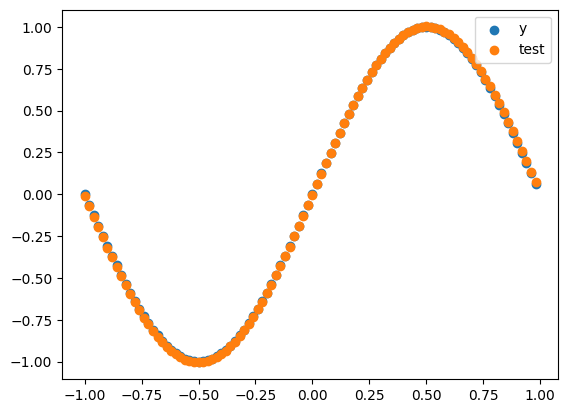

In [23]:
plt.scatter(X, y, label="y")
plt.scatter(X, test, label="test")

plt.legend()
plt.show()